In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

deals_df = pd.read_csv("clear_deals.csv")
projects_df = pd.read_csv("clear_projects.csv")

In [139]:
projects_df

,id_корпуса,проект,класс_проекта,девелопер,конструкция_дома,этажей_от,этажей_до,адрес,плановая_дата_рвэ,стадия_строительства,тип_договора_реализации,тип_объекта_недвижимости,этаж,кол-во_комнат,общая_проектная_площадь,количество_лотов
0,014d0676b7339e64e1bced5c91689519,Скандинавия,Комфорт,А101,Монолит-блоки,16,16,"Сосенское пос., д. 23, к. 23.1",2023-11-29,Введен в эксплуатацию,КП,квартира,2.0,1,92.3,3
1,014d0676b7339e64e1bced5c91689519,Скандинавия,Комфорт,А101,Монолит-блоки,16,16,"Сосенское пос., д. 23, к. 23.1",2023-11-29,Введен в эксплуатацию,КП,квартира,2.0,2,197.1,4
2,014d0676b7339e64e1bced5c91689519,Скандинавия,Комфорт,А101,Монолит-блоки,16,16,"Сосенское пос., д. 23, к. 23.1",2023-11-29,Введен в эксплуатацию,КП,квартира,2.0,4,75.5,1
3,014d0676b7339e64e1bced5c91689519,Скандинавия,Комфорт,А101,Монолит-блоки,16,16,"Сосенское пос., д. 23, к. 23.1",2023-11-29,Введен в эксплуатацию,КП,квартира,2.0,3,65.6,1
4,014d0676b7339e64e1bced5c91689519,Скандинавия,Комфорт,А101,Монолит-блоки,16,16,"Сосенское пос., д. 23, к. 23.1",2023-11-29,Введен в эксплуатацию,КП,квартира,3.0,1,87.6,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21268,beb25d14b14a66f4ffcbc69b37646185,Родные кварталы,Комфорт,А101,Монолит-блоки,10,10,"Марушкинское пос., 33 кв-л, д. 1, к. 1.1",2026-06-30,Монтажные и отделочные работы,ДДУ с эскроу,квартира,10.0,3,155.9,2
21269,beb25d14b14a66f4ffcbc69b37646185,Родные кварталы,Комфорт,А101,Монолит-блоки,10,10,"Марушкинское пос., 33 кв-л, д. 1, к. 1.1",2026-06-30,Монтажные и отделочные работы,ДДУ с эскроу,квартира,10.0,ст,131.3,5
21270,beb25d14b14a66f4ffcbc69b37646185,Родные кварталы,Комфорт,А101,Монолит-блоки,10,10,"Марушкинское пос., 33 кв-л, д. 1, к. 1.1",2026-06-30,Монтажные и отделочные работы,ДДУ с эскроу,квартира,10.0,2,143.4,3
21271,beb25d14b14a66f4ffcbc69b37646185,Родные кварталы,Комфорт,А101,Монолит-блоки,10,10,"Марушкинское пос., 33 кв-л, д. 1, к. 1.1",2026-06-30,Монтажные и отделочные работы,ДДУ с эскроу,квартира,10.0,3,71.2,1


In [140]:
projects_buildings_df = (
    projects_df[projects_df["тип_объекта_недвижимости"] == "квартира"]
    .groupby("id_корпуса")
    .agg(
        # стадия строительства корпус
        стадия_строительства=("стадия_строительства", "first"),

        # этажность дома
        building_floors_count=("этаж", "nunique"),

        # общее количество квартир в корпусе
        total_flats_in_building=("количество_лотов", "sum"),

        плановая_дата_рвэ=("плановая_дата_рвэ", "first"),
    )
    .reset_index()
)

projects_buildings_df.head()


,id_корпуса,стадия_строительства,building_floors_count,total_flats_in_building,плановая_дата_рвэ
0,002b4f20e97d6ca8ac349b5e2e9e81d3,Монтажные и отделочные работы,15,315,2025-12-31
1,0076fc28a53eb506b7fc91475d31dea3,Монтажные и отделочные работы,9,157,2025-08-14
2,0081bc4d4059f46b3b42276ba8aee782,Введен в эксплуатацию,17,549,2025-08-21
3,009d5290e93e353bb27e3f01b505f5b7,Монтажные и отделочные работы,16,695,2026-12-31
4,013e43142be6303646e81ccd28432986,Введен в эксплуатацию,17,185,2025-06-17


In [141]:
deals_count_by_building_df = (
    deals_df[deals_df["тип_лота"] == "квартира"]
    .groupby("id_корпуса")
    .size()
    .reset_index(name="deals_count")
)

deals_count_by_building_df.head()


,id_корпуса,deals_count
0,002b4f20e97d6ca8ac349b5e2e9e81d3,267
1,0076fc28a53eb506b7fc91475d31dea3,98
2,0081bc4d4059f46b3b42276ba8aee782,312
3,009d5290e93e353bb27e3f01b505f5b7,28
4,013e43142be6303646e81ccd28432986,154


In [142]:
projects_buildings_df = projects_buildings_df.merge(
    deals_count_by_building_df,
    on="id_корпуса",
    how="left"
)

# если по корпусу не было сделок
projects_buildings_df["deals_count"] = (
    projects_buildings_df["deals_count"]
    .fillna(0)
    .astype(int)
)


In [143]:
projects_buildings_df

,id_корпуса,стадия_строительства,building_floors_count,total_flats_in_building,плановая_дата_рвэ,deals_count
0,002b4f20e97d6ca8ac349b5e2e9e81d3,Монтажные и отделочные работы,15,315,2025-12-31,267
1,0076fc28a53eb506b7fc91475d31dea3,Монтажные и отделочные работы,9,157,2025-08-14,98
2,0081bc4d4059f46b3b42276ba8aee782,Введен в эксплуатацию,17,549,2025-08-21,312
3,009d5290e93e353bb27e3f01b505f5b7,Монтажные и отделочные работы,16,695,2026-12-31,28
4,013e43142be6303646e81ccd28432986,Введен в эксплуатацию,17,185,2025-06-17,154
...,...,...,...,...,...,...
407,fd01b8c0e5ea83c9252268d6806cf6e6,Монтажные и отделочные работы,20,264,2027-03-31,73
408,fd11279466f6069c8fefd1baa5884d18,Введен в эксплуатацию,13,377,2023-06-30,134
409,fde1f8ad4322f757d44bdf4c634df283,Введен в эксплуатацию,17,185,2025-05-30,153
410,fe3fbf2588f1c241871893ab71fee571,Монтажные и отделочные работы,9,63,2026-06-30,34


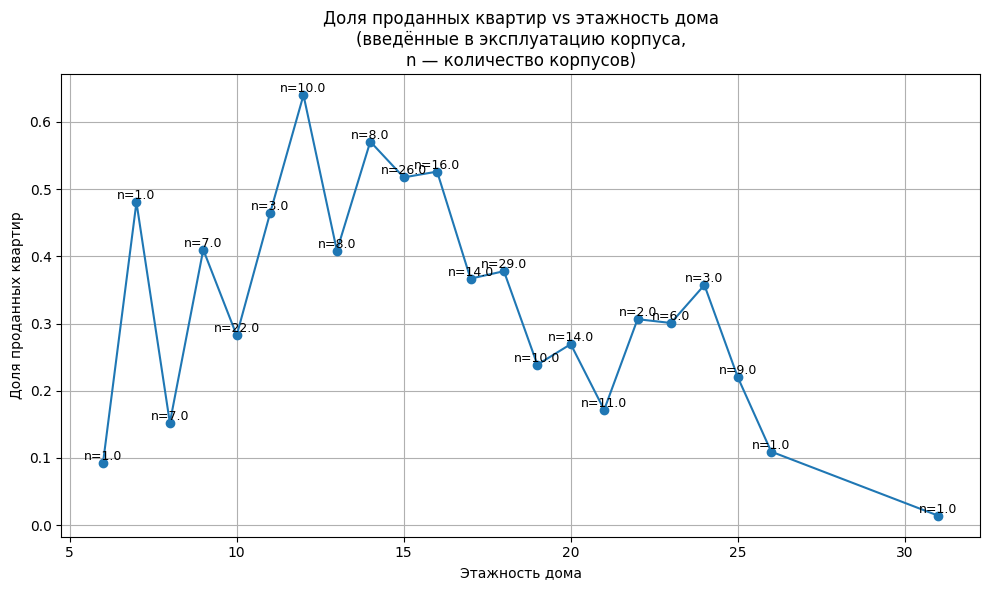

In [ ]:
commissioned_buildings_df = projects_buildings_df[
    projects_buildings_df["стадия_строительства"] != "Введен в эксплуатацию"
].copy()

commissioned_buildings_df["sales_share"] = (
    commissioned_buildings_df["deals_count"]
    / commissioned_buildings_df["total_flats_in_building"]
)

height_sales_share_commissioned_df = (
    commissioned_buildings_df
    .groupby("building_floors_count")
    .agg(
        mean_sales_share=("sales_share", "mean"),
        buildings_count=("id_корпуса", "count")
    )
    .reset_index()
)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    height_sales_share_commissioned_df["building_floors_count"],
    height_sales_share_commissioned_df["mean_sales_share"],
    marker="o"
)

# подписи n над точками
for _, row in height_sales_share_commissioned_df.iterrows():
    plt.text(
        row["building_floors_count"],
        row["mean_sales_share"],
        f'n={row["buildings_count"]}',
        fontsize=9,
        ha='center',
        va='bottom'
    )

plt.xlabel("Этажность дома")
plt.ylabel("Доля проданных квартир")
plt.title(
    "Доля проданных квартир vs этажность дома\n"
    "(введённые в эксплуатацию корпуса,\n"
    "n — количество корпусов)"
)

plt.grid(True)
plt.tight_layout()
plt.show()



Коэффициент наклона (β1): -0.0092
Свободный член (β0): 0.5203
R² (взвешенный): 0.098


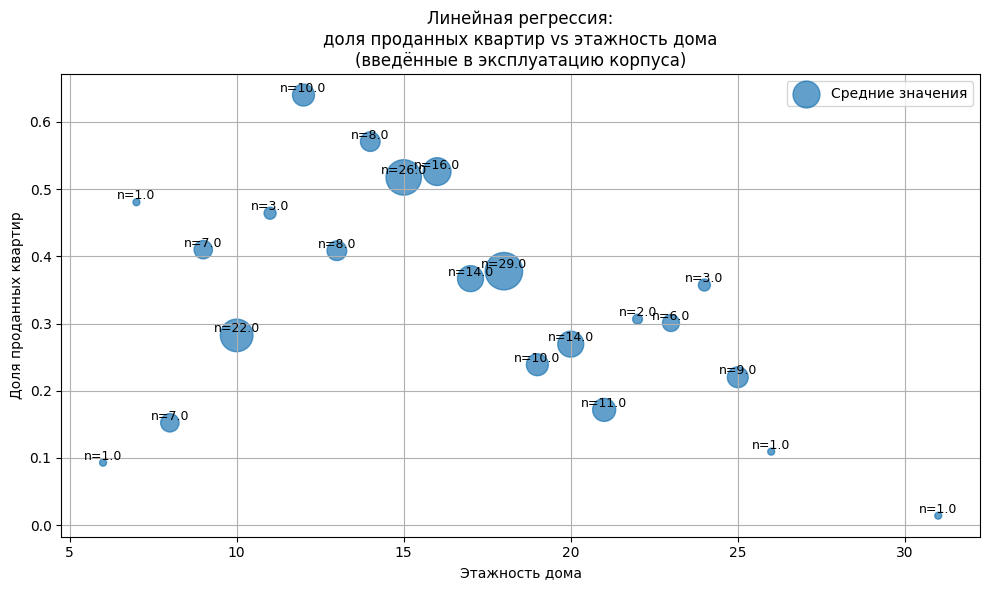

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# X, y, веса
X = height_sales_share_commissioned_df["building_floors_count"].values.reshape(-1, 1)
y = height_sales_share_commissioned_df["mean_sales_share"].values
weights = height_sales_share_commissioned_df["buildings_count"].values

# модель
lin_reg = LinearRegression()
lin_reg.fit(X, y, sample_weight=weights)

# предсказания
x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = lin_reg.predict(x_line)

# коэффициенты
slope = lin_reg.coef_[0]
intercept = lin_reg.intercept_
r2 = lin_reg.score(X, y, sample_weight=weights)

print(f"Коэффициент наклона (β1): {slope:.4f}")
print(f"Свободный член (β0): {intercept:.4f}")
print(f"R² (взвешенный): {r2:.3f}")

plt.figure(figsize=(10, 6))

# точки
plt.scatter(
    height_sales_share_commissioned_df["building_floors_count"],
    height_sales_share_commissioned_df["mean_sales_share"],
    s=height_sales_share_commissioned_df["buildings_count"] * 25,
    alpha=0.7,
    label="Средние значения"
)

# # линия регрессии
# plt.plot(
#     x_line,
#     y_line,
#     linestyle="--",
#     label="Линейная регрессия"
# )

# подписи n
for _, row in height_sales_share_commissioned_df.iterrows():
    plt.text(
        row["building_floors_count"],
        row["mean_sales_share"],
        f'n={row["buildings_count"]}',
        fontsize=9,
        ha='center',
        va='bottom'
    )

plt.xlabel("Этажность дома")
plt.ylabel("Доля проданных квартир")
plt.title(
    "Линейная регрессия:\n"
    "доля проданных квартир vs этажность дома\n"
    "(введённые в эксплуатацию корпуса)"
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



Коэффициент наклона (β1): -0.0003
Свободный член (β0): 0.7978
R²: 0.097


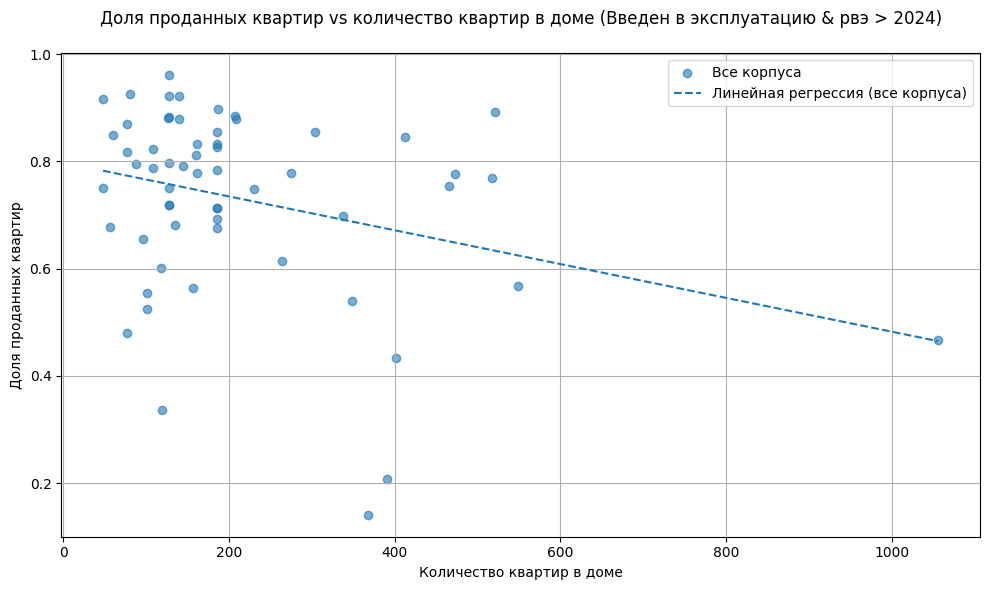

In [268]:
import matplotlib.pyplot as plt

projects_buildings_df["плановая_дата_рвэ"] = pd.to_datetime(
    projects_buildings_df["плановая_дата_рвэ"],
    errors="coerce"
)

start_date = pd.Timestamp("2024-07-01")  # середина 2024

buildings_2023_df = projects_buildings_df[
    (projects_buildings_df["стадия_строительства"] == "Введен в эксплуатацию") &
    (projects_buildings_df["плановая_дата_рвэ"].dt.year > 2024)
].copy()

buildings_2023_df["sales_share"] = (
    buildings_2023_df["deals_count"]
    / buildings_2023_df["total_flats_in_building"]
)

X = buildings_2023_df["total_flats_in_building"].values.reshape(-1, 1)
y = buildings_2023_df["sales_share"].values

model_all = LinearRegression()
model_all.fit(X, y)

x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = model_all.predict(x_line)

print(f"Коэффициент наклона (β1): {model_all.coef_[0]:.4f}")
print(f"Свободный член (β0): {model_all.intercept_:.4f}")
print(f"R²: {model_all.score(X, y):.3f}")

plt.figure(figsize=(10, 6))

plt.scatter(
    buildings_2023_df["total_flats_in_building"],
    buildings_2023_df["sales_share"],
    alpha=0.6,
    label="Все корпуса"
)

plt.plot(
    x_line,
    y_line,
    linestyle="--",
    label="Линейная регрессия (все корпуса)"
)

plt.xlabel("Количество квартир в доме")
plt.ylabel("Доля проданных квартир")
plt.title("Доля проданных квартир vs количество квартир в доме (Введен в эксплуатацию & рвэ > 2024)\n")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

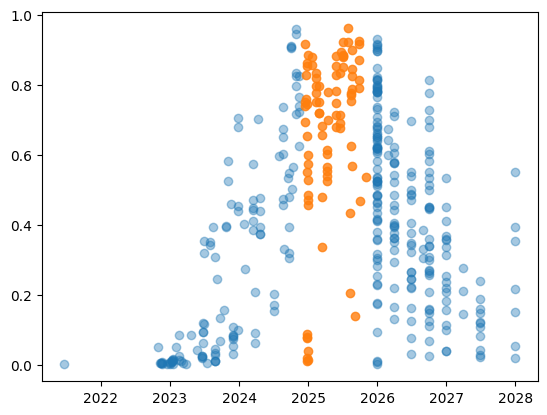

In [267]:
buildings_2023_df = projects_buildings_df.copy()

buildings_2023_df["sales_share"] = (
    buildings_2023_df["deals_count"]
    / buildings_2023_df["total_flats_in_building"]
)

# buildings_2023_df = buildings_2023_df[
#     (buildings_2023_df["стадия_строительства"] == "Введен в эксплуатацию")
# ]

# границы дат
start_date = pd.Timestamp("2024-11-30")  # середина 2024
end_date = pd.Timestamp("2025-11-30")

mask_2024_2026 = (
    (buildings_2023_df["плановая_дата_рвэ"] >= start_date) &
    (buildings_2023_df["плановая_дата_рвэ"] < end_date)
)

# остальные корпуса
plt.scatter(
    buildings_2023_df.loc[~mask_2024_2026, "плановая_дата_рвэ"],
    buildings_2023_df.loc[~mask_2024_2026, "sales_share"],
    alpha=0.4,
    label="Остальные корпуса"
)

# выделенные корпуса
plt.scatter(
    buildings_2023_df.loc[mask_2024_2026, "плановая_дата_рвэ"],
    buildings_2023_df.loc[mask_2024_2026, "sales_share"],
    alpha=0.8,
    label="РВЭ: II пол. 2024 – 2025"
)

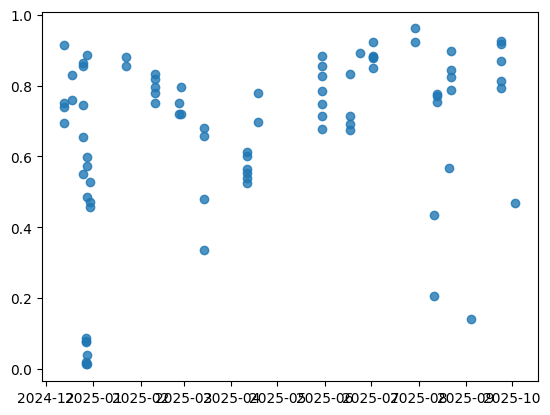

In [250]:
buildings_2023_df = projects_buildings_df.copy()

buildings_2023_df["sales_share"] = (
    buildings_2023_df["deals_count"]
    / buildings_2023_df["total_flats_in_building"]
)

buildings_2023_df = buildings_2023_df[
    (buildings_2023_df["плановая_дата_рвэ"] >= start_date) &
    (buildings_2023_df["стадия_строительства"] == "Введен в эксплуатацию")
]

# остальные корпуса
plt.scatter(
    buildings_2023_df["плановая_дата_рвэ"],
    buildings_2023_df["sales_share"],
    alpha=0.8,
    label="II пол. 2024 – 2025"
)

In [251]:
buildings_2023_df

,id_корпуса,стадия_строительства,building_floors_count,total_flats_in_building,плановая_дата_рвэ,deals_count,sales_share
2,0081bc4d4059f46b3b42276ba8aee782,Введен в эксплуатацию,17,549,2025-08-21,312,0.568306
4,013e43142be6303646e81ccd28432986,Введен в эксплуатацию,17,185,2025-06-17,154,0.832432
9,059550c08c9b9a9f1a38d43293930e67,Введен в эксплуатацию,10,101,2025-04-11,53,0.524752
24,0cf1f9c7f125467ce3cc55ebdebebdff,Введен в эксплуатацию,7,77,2025-09-24,67,0.870130
31,13c6f29672bb831d33d68821fc8154c2,Введен в эксплуатацию,15,128,2025-02-27,102,0.796875
...,...,...,...,...,...,...,...
395,f2a7656b4ff8255fc8a7d933d6f7caaa,Введен в эксплуатацию,15,412,2025-08-22,348,0.844660
396,f31485515548fc6a35df57b5a2c0cd2b,Введен в эксплуатацию,22,1056,2025-10-03,494,0.467803
403,f88eb31294efa9ae4e42d6eea84414cc,Введен в эксплуатацию,15,128,2025-07-30,118,0.921875
405,fc7dbe2d2ed10547d097316bf6a10e3b,Введен в эксплуатацию,17,185,2025-05-30,158,0.854054


In [252]:
median_sales_share = buildings_2023_df["sales_share"].median()

buildings_2023_df["sales_share_group"] = (
    buildings_2023_df["sales_share"] >= median_sales_share
).map({
    True: "Выше_или_равно_медианы",
    False: "Ниже_медианы"
})
buildings_2023_df

,id_корпуса,стадия_строительства,building_floors_count,total_flats_in_building,плановая_дата_рвэ,deals_count,sales_share,sales_share_group
2,0081bc4d4059f46b3b42276ba8aee782,Введен в эксплуатацию,17,549,2025-08-21,312,0.568306,Ниже_медианы
4,013e43142be6303646e81ccd28432986,Введен в эксплуатацию,17,185,2025-06-17,154,0.832432,Выше_или_равно_медианы
9,059550c08c9b9a9f1a38d43293930e67,Введен в эксплуатацию,10,101,2025-04-11,53,0.524752,Ниже_медианы
24,0cf1f9c7f125467ce3cc55ebdebebdff,Введен в эксплуатацию,7,77,2025-09-24,67,0.870130,Выше_или_равно_медианы
31,13c6f29672bb831d33d68821fc8154c2,Введен в эксплуатацию,15,128,2025-02-27,102,0.796875,Выше_или_равно_медианы
...,...,...,...,...,...,...,...,...
395,f2a7656b4ff8255fc8a7d933d6f7caaa,Введен в эксплуатацию,15,412,2025-08-22,348,0.844660,Выше_или_равно_медианы
396,f31485515548fc6a35df57b5a2c0cd2b,Введен в эксплуатацию,22,1056,2025-10-03,494,0.467803,Ниже_медианы
403,f88eb31294efa9ae4e42d6eea84414cc,Введен в эксплуатацию,15,128,2025-07-30,118,0.921875,Выше_или_равно_медианы
405,fc7dbe2d2ed10547d097316bf6a10e3b,Введен в эксплуатацию,17,185,2025-05-30,158,0.854054,Выше_или_равно_медианы


In [253]:
stats_by_group = (
    buildings_2023_df
    .groupby("sales_share_group")
    .agg(
        count_buildings=("id_корпуса", "count"),
        sales_share_mean=("sales_share", "mean"),
        sales_share_median=("sales_share", "median"),
        sales_share_std=("sales_share", "std"),
        sales_share_min=("sales_share", "min"),
        sales_share_p25=("sales_share", lambda x: x.quantile(0.25)),
        sales_share_p75=("sales_share", lambda x: x.quantile(0.75)),
        sales_share_max=("sales_share", "max"),

        total_flats_mean=("total_flats_in_building", "mean"),
        total_flats_median=("total_flats_in_building", "median"),

        deals_count_mean=("deals_count", "mean"),
        deals_count_median=("deals_count", "median"),

        floors_mean=("building_floors_count", "mean"),
        floors_median=("building_floors_count", "median"),
    )
    .round(3)
)
stats_by_group

,count_buildings,sales_share_mean,sales_share_median,sales_share_std,sales_share_min,sales_share_p25,sales_share_p75,sales_share_max,total_flats_mean,total_flats_median,deals_count_mean,deals_count_median,floors_mean,floors_median
sales_share_group,,,,,,,,,,,,,,
Выше_или_равно_медианы,42,0.839,0.839,0.057,0.750,0.788,0.882,0.961,233.619,162.0,195.619,132.5,13.500,14.5
Ниже_медианы,42,0.490,0.559,0.240,0.013,0.440,0.681,0.748,269.048,207.0,130.524,105.5,12.786,11.5


In [254]:
project_area_agg = (
    projects_df
    .groupby("id_корпуса")
    .agg(
        total_project_area=("общая_проектная_площадь", "sum"),
        total_lots=("количество_лотов", "sum")
    )
    .reset_index()
)

project_area_agg["avg_flat_area"] = (
    project_area_agg["total_project_area"]
    / project_area_agg["total_lots"]
)

project_area_agg

price_agg = (
    deals_df
    .groupby("id_корпуса")
    .agg(
        total_deal_area=("площадь_объекта", "sum"),
        total_deal_budget=("реальная_сумма_бюджета", "sum"),
        deals_count=("id_корпуса", "count")
    )
    .reset_index()
)

price_agg["avg_price_per_sqm"] = (
    price_agg["total_deal_budget"]
    / price_agg["total_deal_area"]
)

buildings_2023_df = (
    buildings_2023_df
    .merge(
        project_area_agg[["id_корпуса", "avg_flat_area"]],
        on="id_корпуса",
        how="left"
    )
    .merge(
        price_agg[["id_корпуса", "avg_price_per_sqm"]],
        on="id_корпуса",
        how="left"
    )
)

buildings_2023_df


,id_корпуса,стадия_строительства,building_floors_count,total_flats_in_building,плановая_дата_рвэ,deals_count,sales_share,sales_share_group,avg_flat_area,avg_price_per_sqm
0,0081bc4d4059f46b3b42276ba8aee782,Введен в эксплуатацию,17,549,2025-08-21,312,0.568306,Ниже_медианы,41.895902,211137.297571
1,013e43142be6303646e81ccd28432986,Введен в эксплуатацию,17,185,2025-06-17,154,0.832432,Выше_или_равно_медианы,48.218421,230538.094875
2,059550c08c9b9a9f1a38d43293930e67,Введен в эксплуатацию,10,101,2025-04-11,53,0.524752,Ниже_медианы,35.475303,194094.698758
3,0cf1f9c7f125467ce3cc55ebdebebdff,Введен в эксплуатацию,7,77,2025-09-24,67,0.870130,Выше_или_равно_медианы,55.817442,215736.937259
4,13c6f29672bb831d33d68821fc8154c2,Введен в эксплуатацию,15,128,2025-02-27,102,0.796875,Выше_или_равно_медианы,49.845522,265906.011004
...,...,...,...,...,...,...,...,...,...,...
79,f2a7656b4ff8255fc8a7d933d6f7caaa,Введен в эксплуатацию,15,412,2025-08-22,348,0.844660,Выше_или_равно_медианы,34.590244,234309.278344
80,f31485515548fc6a35df57b5a2c0cd2b,Введен в эксплуатацию,22,1056,2025-10-03,494,0.467803,Ниже_медианы,33.160797,253318.092669
81,f88eb31294efa9ae4e42d6eea84414cc,Введен в эксплуатацию,15,128,2025-07-30,118,0.921875,Выше_или_равно_медианы,49.902273,265378.060341
82,fc7dbe2d2ed10547d097316bf6a10e3b,Введен в эксплуатацию,17,185,2025-05-30,158,0.854054,Выше_или_равно_медианы,48.203684,225271.493152


In [265]:
from scipy import stats

low_group = buildings_2023_df.loc[
    buildings_2023_df["sales_share_group"] == "Ниже_медианы",
    "avg_flat_area"
]

high_group = buildings_2023_df.loc[
    buildings_2023_df["sales_share_group"] == "Выше_или_равно_медианы",
    "avg_flat_area"
]

t_stat, p_value = stats.ttest_ind(
    low_group,
    high_group,
    equal_var=False
)

print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.4f}")

print(f"Mean (Ниже медианы): {low_group.mean():.1f}")
print(f"Mean (Выше медианы): {high_group.mean():.1f}")


t-statistic: 0.050
p-value: 0.9600
Mean (Ниже медианы): 46.0
Mean (Выше медианы): 45.9


In [257]:
buildings_2023_df["flats_per_floor"] = (
    buildings_2023_df["total_flats_in_building"]
    / buildings_2023_df["building_floors_count"]
).round()
buildings_2023_df["flats_per_floor"]

0     32.0
1     11.0
2     10.0
3     11.0
4      9.0
      ... 
79    27.0
80    48.0
81     9.0
82    11.0
83    11.0
Name: flats_per_floor, Length: 84, dtype: float64

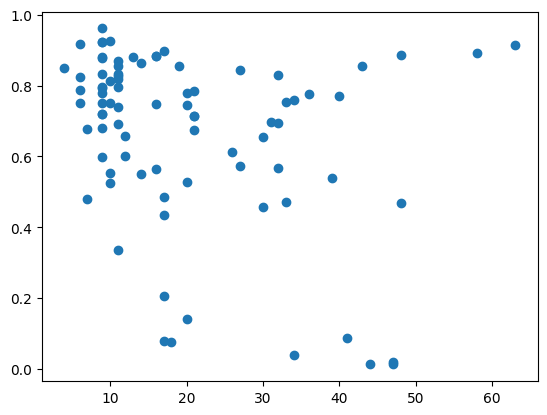

In [258]:
plt.scatter(buildings_2023_df["flats_per_floor"], buildings_2023_df["sales_share"])

In [259]:
import pandas as pd

corr_df = buildings_2023_df[[
    "sales_share",
    "deals_count",
    "total_flats_in_building",
    "building_floors_count",
    "avg_price_per_sqm",
    "avg_flat_area"
]]

corr_matrix = corr_df.corr(method="pearson").round(3)
corr_matrix

,sales_share,deals_count,total_flats_in_building,building_floors_count,avg_price_per_sqm,avg_flat_area
sales_share,1.000,0.356,-0.086,0.221,0.691,-0.072
deals_count,0.356,1.000,0.859,0.335,0.247,-0.493
total_flats_in_building,-0.086,0.859,1.000,0.391,0.011,-0.460
building_floors_count,0.221,0.335,0.391,1.000,0.541,-0.209
avg_price_per_sqm,0.691,0.247,0.011,0.541,1.000,-0.061
avg_flat_area,-0.072,-0.493,-0.460,-0.209,-0.061,1.000


                            OLS Regression Results                            
Dep. Variable:            sales_share   R-squared:                       0.530
Model:                            OLS   Adj. R-squared:                  0.500
Method:                 Least Squares   F-statistic:                     17.57
Date:                Mon, 15 Dec 2025   Prob (F-statistic):           1.28e-11
Time:                        12:55:01   Log-Likelihood:                 30.466
No. Observations:                  84   AIC:                            -48.93
Df Residuals:                      78   BIC:                            -34.35
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

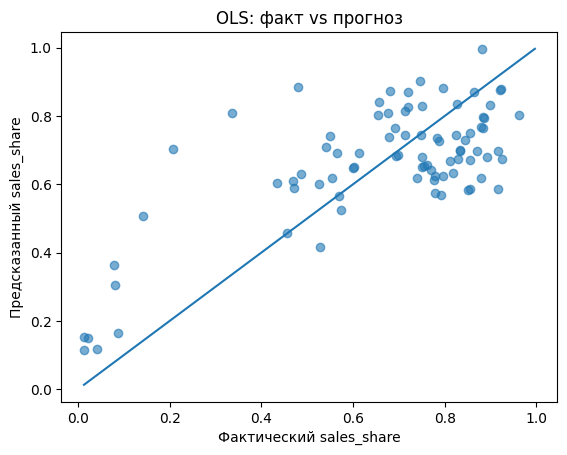

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

features = [
    "total_flats_in_building",
    "building_floors_count",
    "avg_flat_area",
    "flats_per_floor",
    "avg_price_per_sqm",
    
]

df_reg = buildings_2023_df[features + ["sales_share"]].copy()

# приведение к numeric
for c in features + ["sales_share"]:
    df_reg[c] = pd.to_numeric(df_reg[c], errors="coerce")

# чистка
df_reg = (
    df_reg
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

X = sm.add_constant(df_reg[features])
y = df_reg["sales_share"]

model = sm.OLS(y, X).fit()

print(model.summary())
print(f"R² = {model.rsquared:.3f}")
print(f"Adj. R² = {model.rsquared_adj:.3f}")

y_pred = model.predict(X)

plt.figure()
plt.scatter(y, y_pred, alpha=0.6)

min_val = min(y.min(), y_pred.min())
max_val = max(y.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Фактический sales_share")
plt.ylabel("Предсказанный sales_share")
plt.title("OLS: факт vs прогноз")
plt.show()


R² = 0.021


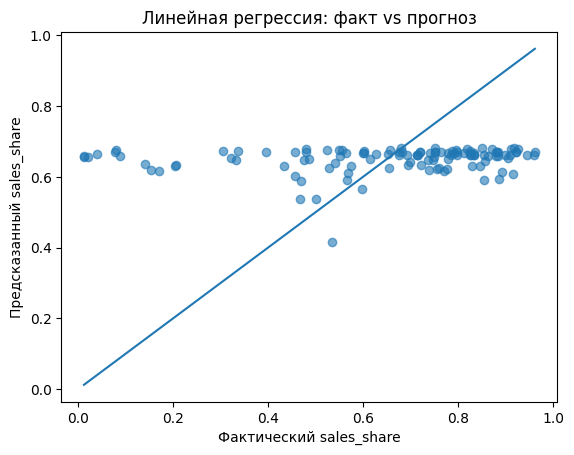

In [200]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

X = buildings_2023_df[
    [
        "total_flats_in_building"
    ]
]
y = buildings_2023_df["sales_share"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

y_pred = model.predict(X)

plt.figure()

plt.scatter(
    y,
    y_pred,
    alpha=0.6
)

# линия идеального совпадения
min_val = min(y.min(), y_pred.min())
max_val = max(y.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val]
)

plt.xlabel("Фактический sales_share")
plt.ylabel("Предсказанный sales_share")
plt.title("Линейная регрессия: факт vs прогноз")

model.rsquared
print(f"R² = {model.rsquared:.3f}")

plt.show()

Коэффициент наклона (β1): -0.0001
Свободный член (β0): 0.6887
R²: 0.021


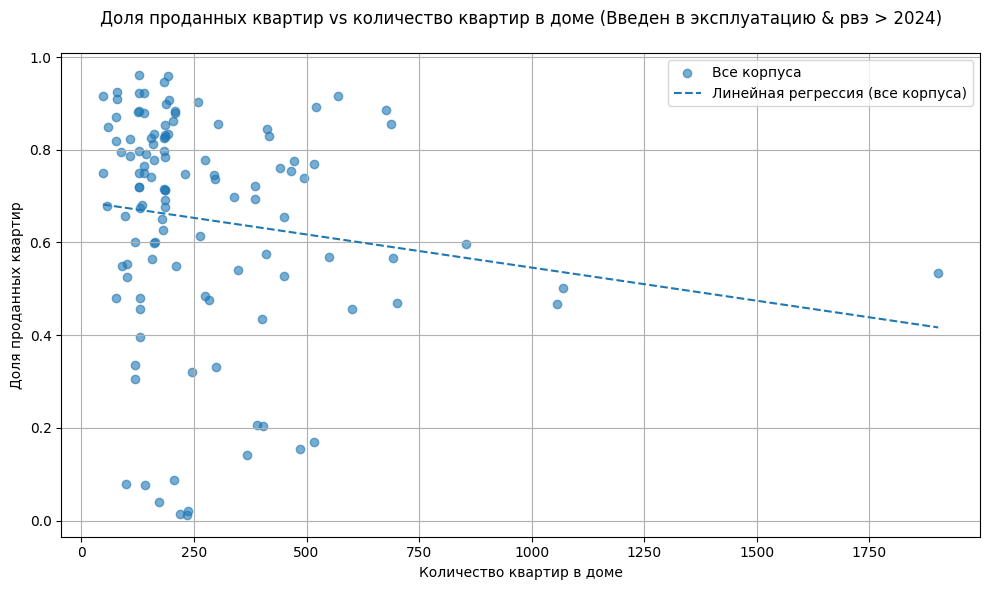

In [201]:
import matplotlib.pyplot as plt

X = buildings_2023_df["total_flats_in_building"].values.reshape(-1, 1)
y = buildings_2023_df["sales_share"].values

model_all = LinearRegression()
model_all.fit(X, y)

x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = model_all.predict(x_line)

print(f"Коэффициент наклона (β1): {model_all.coef_[0]:.4f}")
print(f"Свободный член (β0): {model_all.intercept_:.4f}")
print(f"R²: {model_all.score(X, y):.3f}")

plt.figure(figsize=(10, 6))

plt.scatter(
    buildings_2023_df["total_flats_in_building"],
    buildings_2023_df["sales_share"],
    alpha=0.6,
    label="Все корпуса"
)

plt.plot(
    x_line,
    y_line,
    linestyle="--",
    label="Линейная регрессия (все корпуса)"
)

plt.xlabel("Количество квартир в доме")
plt.ylabel("Доля проданных квартир")
plt.title("Доля проданных квартир vs количество квартир в доме (Введен в эксплуатацию & рвэ > 2024)\n")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()